# Cyber Threat Forecasting: B-MTGNN Model Verification

## Environment & Path Setup
Imports the required standard libraries and appends the project root to the system path to allow Python to locate custom project modules. Sets the working directory to the B-MTGNN folder.

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import torch

import torch.optim as optim
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt

# Get the directory where this notebook is running
current_dir = os.getcwd()

# Assume the project root is one level up
project_root = os.path.abspath(os.path.join(current_dir, '..'))

# Add to sys.path if not already there
if project_root not in sys.path:
    sys.path.append(project_root)

print(f"Project Root added to path: {project_root}")

# Set working directory to the B-MTGNN folder for script execution
bmtgnn_dir = os.path.join(project_root, 'B-MTGNN')
if os.path.exists(bmtgnn_dir):
    os.chdir(bmtgnn_dir)
    print(f"Working directory set to: {os.getcwd()}")
else:
    print(f"Directory not found: {bmtgnn_dir}")

# Import custom modules    
import util
import net

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Setup Complete. Running on: {device}")

## Configuration & Constants

Defines the experimental hyperparameters. Sets the training and validation splits to match the values from the original paper, alongside the 10-month input window and 36-month forecast horizon.

In [3]:
# --- B-MTGNN Benchmark Settings ---
CONSTANTS = {
    'TRAIN_SPLIT': 0.43,
    'VAL_SPLIT': 0.30,
    'TEST_SPLIT': 0.27,      # Remaining data
    'WINDOW_SIZE': 10,       # 10 Months History
    'FORECAST_HORIZON': 36,  # 3 Years Future
    'BATCH_SIZE': 16,
    'LEARNING_RATE': 0.001,
    'EPOCHS': 5              # Short run for verification
}

print("Experimental Settings:")
print(f" - Train Split: {CONSTANTS['TRAIN_SPLIT']}")
print(f" - Validation Split: {CONSTANTS['VAL_SPLIT']}")
print(f" - Input Window: {CONSTANTS['WINDOW_SIZE']} Months")
print(f" - Forecast Horizon: {CONSTANTS['FORECAST_HORIZON']} Months")

Experimental Settings:
 - Train Split: 0.43
 - Validation Split: 0.3
 - Input Window: 10 Months
 - Forecast Horizon: 36 Months


## Data Preprocessing Execution

Executes the preprocessing script to generate the text-based time-series arrays and the graph adjacency matrix.

In [ ]:
print("--- Executing Data Preprocessing ---")

# Run the data generation script
!{sys.executable} -W ignore Prep_Unsmoothed_Data.py

print("\nData preprocessing complete. Graph artefacts generated.")

## Data Loading & Tensor Construction

Ingests the preprocessed text data and splits it into PyTorch tensors using the custom data loader. Applies the training and validation splits defined in the configuration and prints the resulting tensor dimensions to verify correct shape construction.

In [4]:
data_path = 'data/sm_data.txt'

print("--- Initialising DataLoader ---")

# Initialise the DataLoader with the constants defined earlier
data = util.DataLoaderS(
    data_path,
    CONSTANTS['TRAIN_SPLIT'],
    CONSTANTS['VAL_SPLIT'],
    device,
    CONSTANTS['FORECAST_HORIZON'],
    CONSTANTS['WINDOW_SIZE'],
    normalize=2
)

# Extract the number of nodes directly from the input tensor shape
# Standard shape expectation: (Samples, Channels, Nodes, Time)
num_nodes = data.train[0].shape[2]

print("Data loading and splitting complete.")
print(f"Number of extracted features (Nodes): {num_nodes}")
print(f"Train X (Input):  {data.train[0].shape}")
print(f"Train Y (Target): {data.train[1].shape}")
print(f"Val X (Input):    {data.valid[0].shape}")
print(f"Val Y (Target):   {data.valid[1].shape}")


--- Initialising DataLoader ---
Graph loaded with 26 attacks...
123 columns loaded...
Adjacency created...
Data loading and splitting complete.
Number of extracted features (Nodes): 142
Train X (Input):  torch.Size([13, 10, 142])
Train Y (Target): torch.Size([13, 1, 142])
Val X (Input):    torch.Size([40, 10, 142])
Val Y (Target):   torch.Size([40, 1, 142])


## Model Initialisation

Loads the predefined adjacency matrix to establish the spatial connections between the cyber threat nodes. Instantiates the B-MTGNN architecture and allocates the model to the designated hardware device.


In [5]:
adj_path = 'data/graph.csv'

print("--- Loading Adjacency Matrix ---")
# Retrieve the pre-computed numeric adjacency tensor directly from the DataLoader object
supports = [data.adj.to(device)]



print("--- Initialising B-MTGNN Model ---")

# Instantiate the model using the parameters from the data loader and configuration
model = net.gtnet(
    gcn_true=True,
    buildA_true=True,
    gcn_depth=2,
    num_nodes=num_nodes,
    device=device,
    predefined_A=supports,
    seq_length=CONSTANTS['WINDOW_SIZE'],
    in_dim=1,
    out_dim=CONSTANTS['FORECAST_HORIZON']
)

# Move model to the selected device
model.to(device)

# Count total trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Model initialisation complete.")
print(f"Total trainable parameters: {total_params:,}")

--- Loading Adjacency Matrix ---
--- Initialising B-MTGNN Model ---
Model initialisation complete.
Total trainable parameters: 314,740


## Training Loop Verification

Executes a short training loop to verify that the optimiser correctly calculates gradients and reduces the loss function over time. Outputs standard validation metrics, specifically Root Relative Squared Error (RSE) and Relative Absolute Error (RAE), to confirm the model is learning from the predefined graph structures.

In [7]:
# Define the evaluation metrics
def compute_metrics(predictions, targets):
    preds_flat = predictions.view(-1)
    targets_flat = targets.view(-1)
    target_mean = torch.mean(targets_flat)
    
    numerator_rse = torch.sqrt(torch.sum((preds_flat - targets_flat) ** 2))
    denominator_rse = torch.sqrt(torch.sum((targets_flat - target_mean) ** 2))
    rse = numerator_rse / (denominator_rse + 1e-7)
    
    numerator_rae = torch.sum(torch.abs(preds_flat - targets_flat))
    denominator_rae = torch.sum(torch.abs(targets_flat - target_mean))
    rae = numerator_rae / (denominator_rae + 1e-7)
    
    return rse.item(), rae.item()

# Initialise the optimiser and loss function
optimiser = optim.Adam(model.parameters(), lr=CONSTANTS['LEARNING_RATE'])
loss_fn = nn.L1Loss(reduction='sum')

print("--- Starting Training Verification ---")

for epoch in range(CONSTANTS['EPOCHS']):
    model.train()
    train_loss = 0.0
    
    # Use Zaid's custom batch generator
    for batch_x, batch_y in data.get_batches(data.train[0], data.train[1], CONSTANTS['BATCH_SIZE'], True):
        optimiser.zero_grad()
        
        # Exact dimension reshaping from train.py
        batch_x = torch.unsqueeze(batch_x, dim=1)
        batch_x = batch_x.transpose(2, 3)
        
        # Slicing to force the view
        tx = batch_x[:, :, :, :]
        ty = batch_y[:, :, :]
        
        output = model(tx)
        
        # Remove the extra dimension from the output
        output = torch.squeeze(output, 3)
        
        # Apply scaling safely without in-place operations
        scale = data.scale.expand(output.size(0), output.size(1), data.m)
        output = output * scale
        ty = ty * scale
        
        loss = loss_fn(output, ty)
        loss.backward()
        optimiser.step()
        
        # Track loss
        train_loss += loss.item()
        
    # Validation step
    model.eval()
    preds_list, targets_list = [], []
    
    with torch.no_grad():
        for batch_x, batch_y in data.get_batches(data.valid[0], data.valid[1], CONSTANTS['BATCH_SIZE'], False):
            
            # Apply the exact same reshape to the validation data
            batch_x = torch.unsqueeze(batch_x, dim=1)
            batch_x = batch_x.transpose(2, 3)
            
            tx = batch_x[:, :, :, :]
            ty = batch_y[:, :, :]
            
            val_output = model(tx)
            val_output = torch.squeeze(val_output, 3)
            
            # Apply scaling safely
            scale = data.scale.expand(val_output.size(0), val_output.size(1), data.m)
            val_output = val_output * scale
            ty = ty * scale
            
            preds_list.append(val_output.cpu())
            targets_list.append(ty.cpu())
            
    # Calculate metrics across the entire validation set
    rse, rae = compute_metrics(torch.cat(preds_list), torch.cat(targets_list))
    
    # Normalise train loss for reporting
    total_samples = len(data.train[0]) * CONSTANTS['FORECAST_HORIZON'] * data.m
    avg_train_loss = train_loss / total_samples
    
    print(f"Epoch {epoch+1}/{CONSTANTS['EPOCHS']} | Train Loss: {avg_train_loss:.4f} | Val RSE: {rse:.4f} | Val RAE: {rae:.4f}")

print("Training loop verification complete.")

--- Starting Training Verification ---
Epoch 1/5 | Train Loss: 891.9341 | Val RSE: 1.0808 | Val RAE: 0.5383
Epoch 2/5 | Train Loss: 558.1378 | Val RSE: 0.9601 | Val RAE: 0.4988
Epoch 3/5 | Train Loss: 419.4754 | Val RSE: 0.9259 | Val RAE: 0.4831
Epoch 4/5 | Train Loss: 354.5563 | Val RSE: 0.8729 | Val RAE: 0.4572
Epoch 5/5 | Train Loss: 328.6461 | Val RSE: 0.8344 | Val RAE: 0.4361
Training loop verification complete.


## Forecast Visualisation

Extracts a single sample from the validation set to visually plot the model's prediction against the ground truth. This confirms that the historical window and the future forecast horizon align correctly on the time axis.

--- Generating Visualisation ---


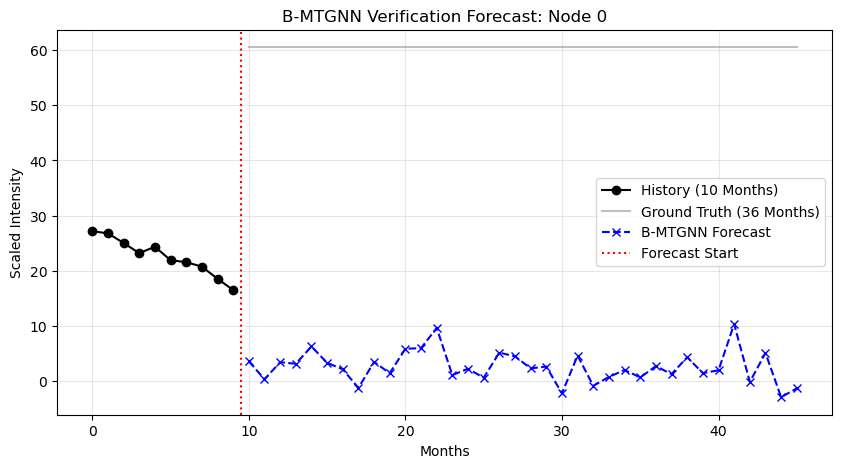

In [9]:
print("--- Generating Visualisation ---")

model.eval()
with torch.no_grad():
    # 1. Grab the first batch using Zaid's custom generator
    batch_iterator = data.get_batches(data.valid[0], data.valid[1], CONSTANTS['BATCH_SIZE'], False)
    batch_x, batch_y = next(batch_iterator)
    
    # 2. Replicate the exact tensor reshaping from Cell 6
    tx = torch.unsqueeze(batch_x, dim=1).transpose(2, 3).to(device)
    ty = batch_y.to(device)
    
    # 3. Generate prediction and format dimensions
    prediction = model(tx)
    prediction = torch.squeeze(prediction, 3)
    
    # 4. Apply scaling to predictions and target
    scale = data.scale.expand(prediction.size(0), prediction.size(1), data.m)
    prediction = prediction * scale
    ty = ty * scale

    # Apply scaling to history so it aligns visually with the forecast
    # batch_x shape is (Batch, Time, Nodes). We isolate node 0.
    history_raw = batch_x[0, :, 0].cpu().numpy()
    scale_node_0 = data.scale[0].cpu().item()
    history = history_raw * scale_node_0

    ground_truth = ty[0, :, 0].cpu().numpy()
    forecast = prediction[0, :, 0].cpu().numpy()

# Define the time axes based on the defined constants
t_history = np.arange(0, CONSTANTS['WINDOW_SIZE'])
t_future = np.arange(CONSTANTS['WINDOW_SIZE'], CONSTANTS['WINDOW_SIZE'] + CONSTANTS['FORECAST_HORIZON'])

# Generate the plot
plt.figure(figsize=(10, 5))
plt.plot(t_history, history, label=f'History ({CONSTANTS["WINDOW_SIZE"]} Months)', marker='o', color='black')
plt.plot(t_future, ground_truth, label=f'Ground Truth ({CONSTANTS["FORECAST_HORIZON"]} Months)', alpha=0.5, color='gray')
plt.plot(t_future, forecast, label='B-MTGNN Forecast', linestyle='--', marker='x', color='blue')

plt.axvline(x=CONSTANTS['WINDOW_SIZE'] - 0.5, color='red', linestyle=':', label='Forecast Start') 
plt.title("B-MTGNN Verification Forecast: Node 0") 
plt.xlabel("Months") 
plt.ylabel("Scaled Intensity") 
plt.legend() 
plt.grid(True, alpha=0.3) 
plt.show()